# Plot 1

In [37]:
import kagglehub
import pandas as pd
import os

In [38]:
# Download latest version
path = kagglehub.dataset_download("sahilislam007/death-rates-by-suicide")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'death-rates-by-suicide' dataset.
Path to dataset files: /kaggle/input/death-rates-by-suicide


In [39]:
# List files in the downloaded dataset directory
print(os.listdir(path))

['Death_rates_for_suicide_by_sex_race_Hispanic_origin_and_age_United.csv']


In [40]:
csv_file_name = 'Death_rates_for_suicide_by_sex_race_Hispanic_origin_and_age_United.csv'
df = pd.read_csv(os.path.join(path, csv_file_name))

print("First 5 rows of the DataFrame:")
df.head()

print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6390 entries, 0 to 6389
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INDICATOR       6390 non-null   object 
 1   UNIT            6390 non-null   object 
 2   UNIT_NUM        6390 non-null   int64  
 3   STUB_NAME       6390 non-null   object 
 4   STUB_NAME_NUM   6390 non-null   int64  
 5   STUB_LABEL      6390 non-null   object 
 6   STUB_LABEL_NUM  6390 non-null   float64
 7   YEAR            6390 non-null   int64  
 8   YEAR_NUM        6390 non-null   int64  
 9   AGE             6390 non-null   object 
 10  AGE_NUM         6390 non-null   float64
 11  ESTIMATE        5484 non-null   float64
 12  FLAG            906 non-null    object 
dtypes: float64(3), int64(4), object(6)
memory usage: 649.1+ KB


## Data Cleaning

In [41]:
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 INDICATOR            0
UNIT                 0
UNIT_NUM             0
STUB_NAME            0
STUB_NAME_NUM        0
STUB_LABEL           0
STUB_LABEL_NUM       0
YEAR                 0
YEAR_NUM             0
AGE                  0
AGE_NUM              0
ESTIMATE           906
FLAG              5484
dtype: int64


Rename 'ESTIMATE' to 'Suicide Rate' for clarity

In [42]:
df.rename(columns={'ESTIMATE': 'Suicide Rate'}, inplace=True)
print("Column 'ESTIMATE' renamed to 'Suicide Rate'.")

Column 'ESTIMATE' renamed to 'Suicide Rate'.


In [43]:
df['Suicide Rate'] = pd.to_numeric(df['Suicide Rate'], errors='coerce')
df.dropna(subset=['Suicide Rate'], inplace=True)
print("Suicide Rate column converted to numeric and NaN rows dropped.")

Suicide Rate column converted to numeric and NaN rows dropped.


Group by age groups. We define 4 age groups from the age ranges given so that we do not have too many age groups.

In [44]:
def assign_age_group(age_label):
    if age_label == 'All ages':
        return None # Exclude 'All ages'
    elif 'years and over' in age_label or '65-74 years' in age_label or '75-84 years' in age_label or '85 years and over' in age_label:
        return '65 years and older'
    elif '45-64 years' in age_label or '45-54 years' in age_label or '55-64 years' in age_label:
        return '45 to 64 years'
    elif '25-44 years' in age_label or '25-34 years' in age_label or '35-44 years' in age_label:
        return '25 to 44 years'
    elif '10-14 years' in age_label or '15-24 years' in age_label or 'Under 1 year' in age_label or '1-4 years' in age_label or '5-9 years' in age_label or '15-19 years' in age_label or '20-24 years' in age_label:
        return '24 years and younger'
    return 'Other'

df['Age Group'] = df['AGE'].apply(assign_age_group)

# Remove rows where Age Group is None (i.e., 'All ages')
df.dropna(subset=['Age Group'], inplace=True)

print("Unique age groups created:", df['Age Group'].unique())

Unique age groups created: ['24 years and younger' '25 to 44 years' '45 to 64 years'
 '65 years and older']


In [45]:
age_group_suicide_rates = df.groupby('Age Group')['Suicide Rate'].mean().reset_index()
print("Average Suicide Rate by Age Group (after refinement):")
display(age_group_suicide_rates)

Average Suicide Rate by Age Group (after refinement):


,Age Group,Suicide Rate
0,24 years and younger,10.683810
1,25 to 44 years,13.992503
2,45 to 64 years,13.847415
3,65 years and older,20.435554


Plotting suicide rates by age group over time

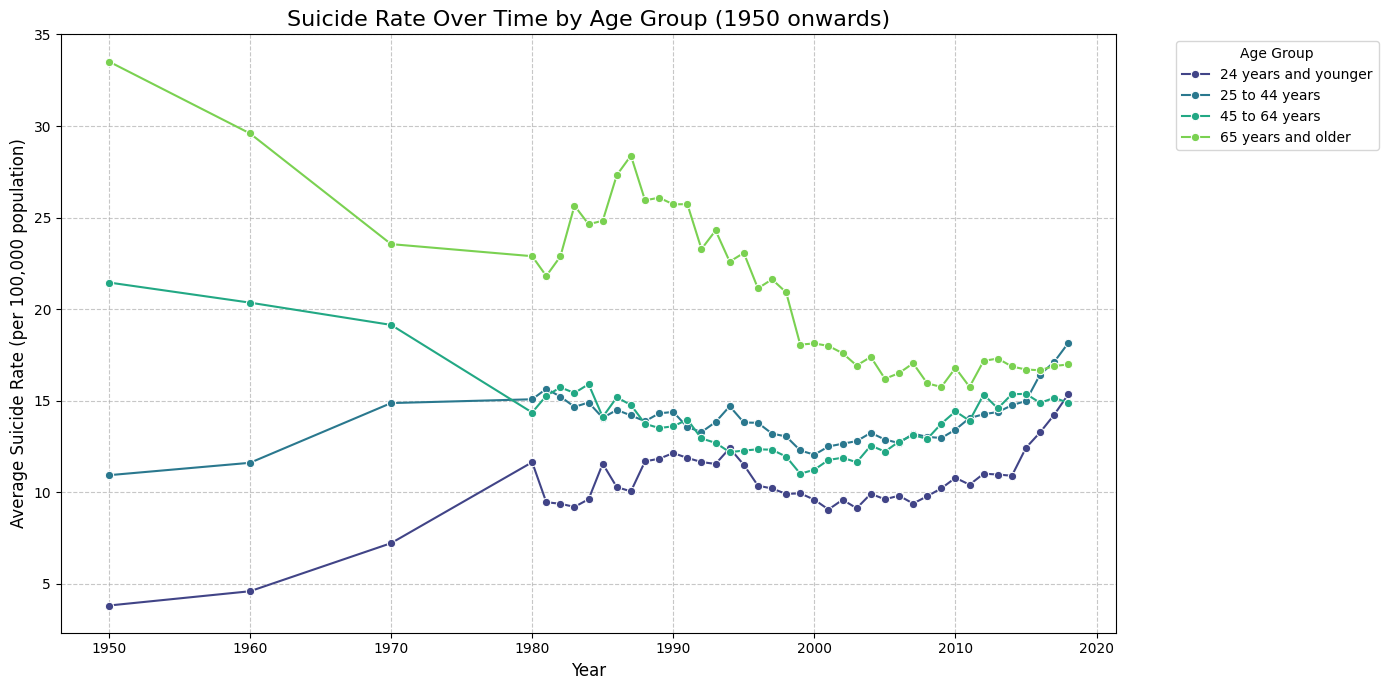

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Group data by year and age group to get the mean suicide rate
trends_df_1950 = df.groupby(['YEAR', 'Age Group'])['Suicide Rate'].mean().reset_index()

# Filter data to start from 1950 (or keep all if it already starts from 1950)
trends_df_1950_filtered = trends_df_1950[trends_df_1950['YEAR'] >= 1950]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=trends_df_1950_filtered,
    x='YEAR',
    y='Suicide Rate',
    hue='Age Group',
    marker='o', # Add markers for clarity
    palette='viridis' # Use a colorblind-friendly palette
)

plt.title('Suicide Rate Over Time by Age Group (1950 onwards)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Suicide Rate (per 100,000 population)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set x-axis tick formatter to display integers
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.tight_layout()
plt.show()

Plotting suicide rate by age group over time from 2000 onwards to focus on recent years.

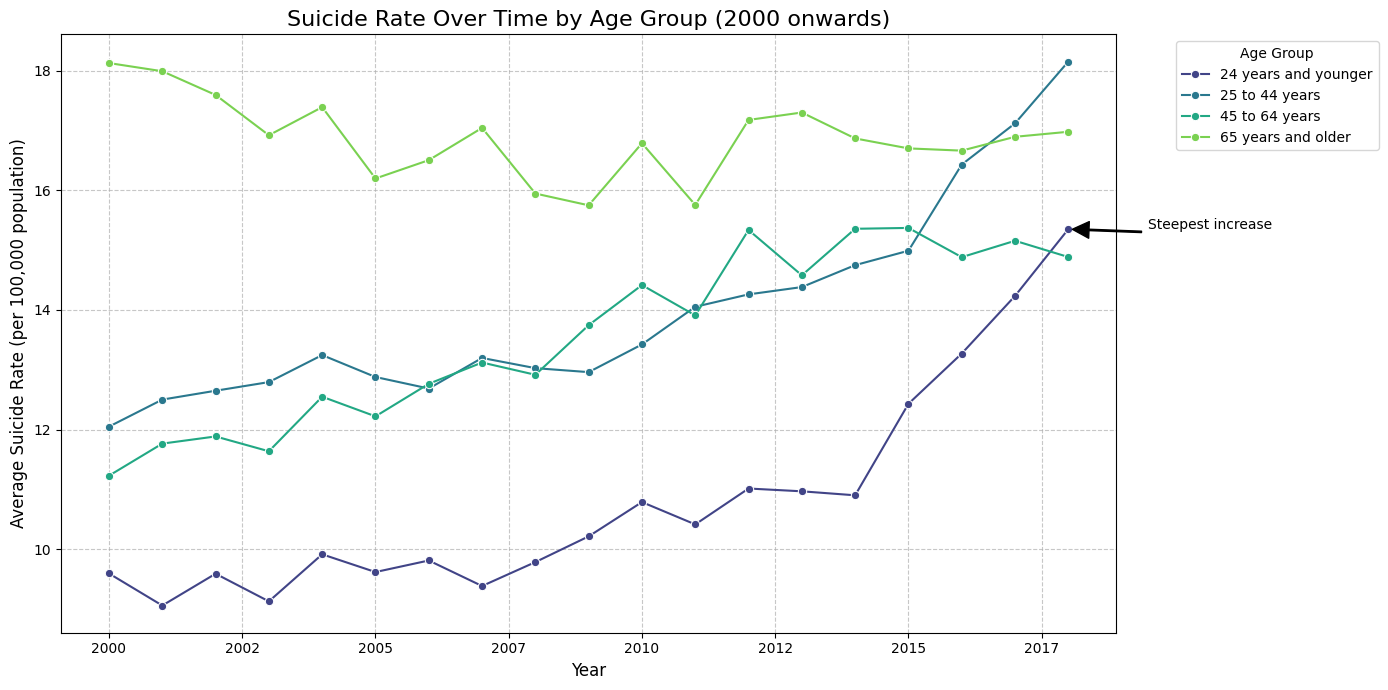

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Group data by year and age group to get the mean suicide rate
trends_df = df.groupby(['YEAR', 'Age Group'])['Suicide Rate'].mean().reset_index()

# Filter data to start from 2000
trends_df_filtered = trends_df[trends_df['YEAR'] >= 2000]

plt.figure(figsize=(14, 7))

# Plot all lines with default linewidth and viridis palette
sns.lineplot(
    data=trends_df_filtered,
    x='YEAR',
    y='Suicide Rate',
    hue='Age Group',
    marker='o', # Add markers for clarity
    palette='viridis', # Use the viridis palette
    linewidth=1.5 # Default linewidth for all
)

plt.title('Suicide Rate Over Time by Age Group (2000 onwards)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Suicide Rate (per 100,000 population)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set x-axis tick formatter to display integers
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# Add annotations
# Get the last data point for the annotated age group
last_year_data = trends_df_filtered[trends_df_filtered['YEAR'] == trends_df_filtered['YEAR'].max()]

age_group_24_younger = last_year_data[last_year_data['Age Group'] == '24 years and younger']
if not age_group_24_younger.empty:
    x_24 = age_group_24_younger['YEAR'].iloc[0]
    y_24 = age_group_24_younger['Suicide Rate'].iloc[0]
    plt.annotate(
        'Steepest increase', # Updated text
        xy=(x_24, y_24),
        xytext=(x_24 + 1.5, y_24), # Offset text slightly
        arrowprops=dict(facecolor='black', shrink=0.05, width=1),
        fontsize=10,
        color='black'
    )


plt.tight_layout()
plt.show()

## Insights

In general, the suicide rate for all age groups have been increasing since 2000. However, the age groups '24 years and younger' and '25 to 44 years' have experienced the sharpest rate of increase, in particular from the early 2010s onward. More resources can be allocated to these age groups in reducing their suicide rates.

# Plot 2

In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-dataset' dataset.
Path to dataset files: /kaggle/input/student-depression-dataset


In [49]:
import os
# List files in the downloaded dataset directory
print(os.listdir(path))

['student_depression_dataset.csv']


In [50]:
csv_file_name = 'student_depression_dataset.csv'
df = pd.read_csv(os.path.join(path, csv_file_name))

print("First 5 rows of the DataFrame:")
df.head()

print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration 

Data Cleaning and Preprocessing

In [51]:
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


In [52]:
df['Financial Stress'] = df['Financial Stress'].replace('?', pd.NA)
df['Financial Stress'] = pd.to_numeric(df['Financial Stress'], errors='coerce')

print("Unique values in 'Financial Stress' after conversion:")
print(df['Financial Stress'].unique())

print("\nData type of 'Financial Stress':")
print(df['Financial Stress'].dtype)

Unique values in 'Financial Stress' after conversion:
[ 1.  2.  5.  3.  4. nan]

Data type of 'Financial Stress':
float64


In [53]:
df['Financial Stress'].isnull().sum()

np.int64(3)

Dropping rows where 'Financial Stress' is null to ensure a complete dataset for this feature.

In [54]:
initial_rows = df.shape[0]
df.dropna(subset=['Financial Stress'], inplace=True)
rows_after_drop = df.shape[0]
print(f"Dropped {initial_rows - rows_after_drop} rows with missing 'Financial Stress' values.")
print(f"Remaining rows: {rows_after_drop}")

# Verify that there are no more missing values in 'Financial Stress'
print(f"Missing values in 'Financial Stress' after dropping: {df['Financial Stress'].isnull().sum()}")

Dropped 3 rows with missing 'Financial Stress' values.
Remaining rows: 27898
Missing values in 'Financial Stress' after dropping: 0


To create the heatmap, we first need to calculate the percentage of depressed individuals for each combination of 'Academic Pressure' and 'Financial Stress'.

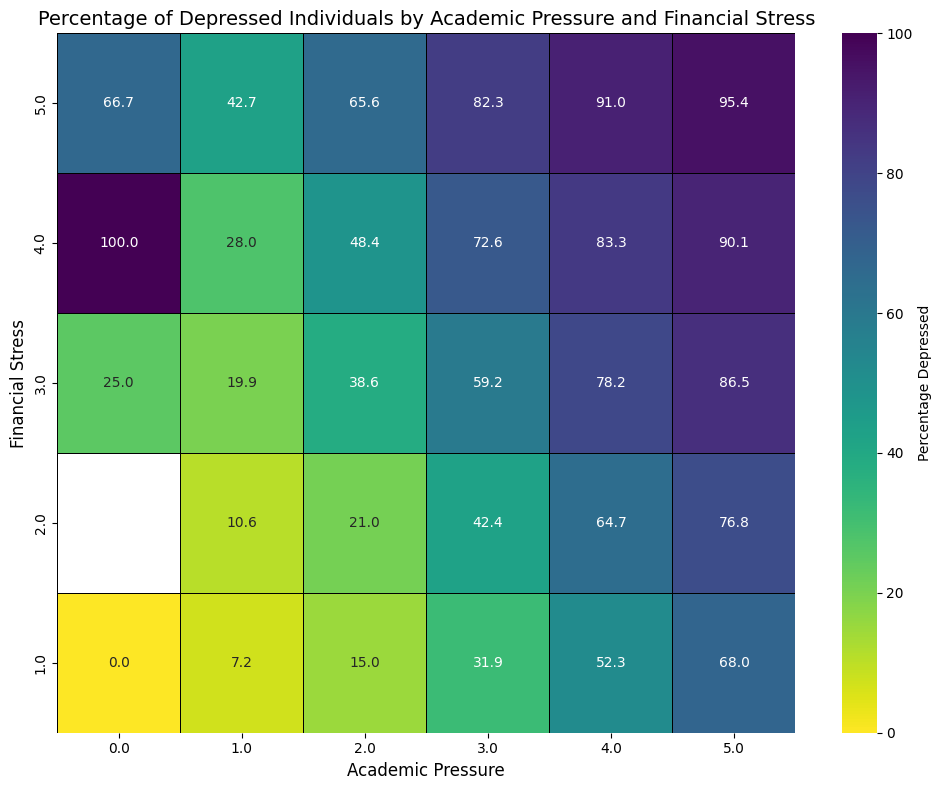

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Academic Pressure' and 'Financial Stress' and calculate the mean of 'Depression'
# Since 'Depression' is 0 or 1, the mean gives the proportion (percentage/100) of depressed individuals
heatmap_data = df.groupby(['Academic Pressure', 'Financial Stress'])['Depression'].mean().reset_index()

# Convert the proportion to a percentage
heatmap_data['Depression Percentage'] = heatmap_data['Depression'] * 100

# Pivot the data for the heatmap
heatmap_pivot = heatmap_data.pivot(
    index='Financial Stress',
    columns='Academic Pressure',
    values='Depression Percentage'
)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_pivot,
    annot=True,     # Show the percentage values on the heatmap
    fmt=".1f",      # Format annotations to one decimal place
    cmap="viridis_r",  # Change color map to viridis_r (reversed viridis)
    linewidths=.5,  # Add lines between cells
    linecolor='black',
    cbar_kws={'label': 'Percentage Depressed'}
)

plt.title('Percentage of Depressed Individuals by Academic Pressure and Financial Stress', fontsize=14)
plt.xlabel('Academic Pressure', fontsize=12)
plt.ylabel('Financial Stress', fontsize=12)
plt.gca().invert_yaxis() # Invert y-axis to have lower financial stress at the bottom
plt.tight_layout()
plt.show()

## Insights

There is a strong positive correlation between both academic pressure and financial stress, and the percentage of individuals experiencing depression. As you move upwards along the x-axis and y-axis the colour of the cell becomes darker, indicating a higher percentage of students depressed. Even when one factor is low, the percentage of students depressed can still be high as long as the other factor is high. The highest percentages of depressed individuals are concentrated in the top-right corner of the heatmap, where both academic pressure and financial stress are at their highest levels. This suggests a cumulative effect where high levels of both stressors create an extremely high risk for depression.

More can be done to reduce academic pressure in schools, as well as financial stress to reduce the risk of depression.

# Plot 3

We will focus on student facing high academic pressure. First, we filter the DataFrame to include only students with 'Academic Pressure' greater than or equal to 3. Then, we visualize the relationship between 'Study Satisfaction' and 'Depression' for this specific group.

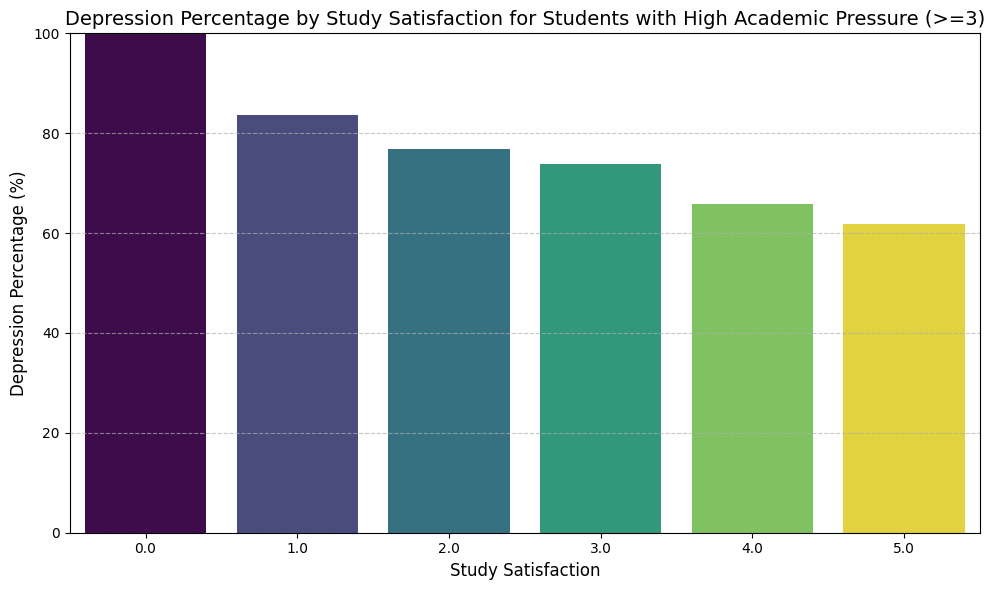

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter students where Academic Pressure >= 3
high_academic_pressure_df = df[df['Academic Pressure'] >= 3]

# Group by 'Study Satisfaction' and calculate the mean of 'Depression'
# (mean of a 0/1 column gives the proportion of 1s, i.e., proportion depressed)
depression_by_study_satisfaction = high_academic_pressure_df.groupby('Study Satisfaction')['Depression'].mean().reset_index()

# Convert to percentage for better readability
depression_by_study_satisfaction['Depression Percentage'] = depression_by_study_satisfaction['Depression'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=depression_by_study_satisfaction,
    x='Study Satisfaction',
    y='Depression Percentage',
    hue='Study Satisfaction', # Assign x to hue as suggested by FutureWarning
    palette='viridis',
    legend=False # Set legend to False as hue is x
)

plt.title('Depression Percentage by Study Satisfaction for Students with High Academic Pressure (>=3)', fontsize=14)
plt.xlabel('Study Satisfaction', fontsize=12)
plt.ylabel('Depression Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%
plt.tight_layout()
plt.show()

Let's generate a bar plot to visualize the 'Depression Percentage' against 'Study Satisfaction' for students experiencing both high academic pressure (>=3) and high financial stress (>=3).

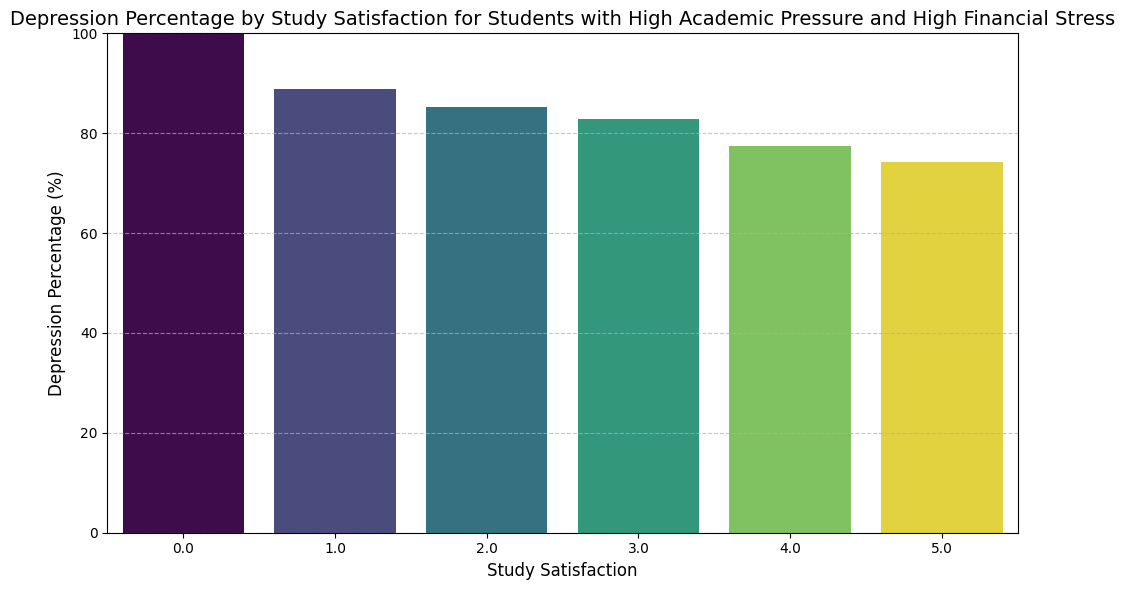

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter students where Academic Pressure >= 3 AND Financial Stress >= 3
high_pressure_high_stress_df = df[(df['Academic Pressure'] >= 3) & (df['Financial Stress'] >= 3)]

# Group by 'Study Satisfaction' and calculate the mean of 'Depression'
depression_by_study_satisfaction_high_stress = high_pressure_high_stress_df.groupby('Study Satisfaction')['Depression'].mean().reset_index()

# Convert to percentage
depression_by_study_satisfaction_high_stress['Depression Percentage'] = depression_by_study_satisfaction_high_stress['Depression'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=depression_by_study_satisfaction_high_stress,
    x='Study Satisfaction',
    y='Depression Percentage',
    hue='Study Satisfaction', # Assign x to hue for coloring and suppress legend
    palette='viridis',
    legend=False
)

plt.title('Depression Percentage by Study Satisfaction for Students with High Academic Pressure and High Financial Stress', fontsize=14)
plt.xlabel('Study Satisfaction', fontsize=12)
plt.ylabel('Depression Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100%
plt.tight_layout()
plt.show()

AI tool disclaimer:
I used Gemini to generate code and ideas for the various plots below. I am responsible for the content and quality of the submitted work.